<a href="https://colab.research.google.com/github/Plogeur/Road2Ten/blob/main/PPO_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import gym
import numpy as np
from gym import spaces
import tensorflow as tf
from tensorflow.keras import layers
from collections import deque
from collections import defaultdict
import random
import matplotlib.pyplot as plt

In [19]:
SEED = 123
random.seed(123)       # Python random
np.random.seed(None)   # NumPy stays fully random

In [20]:
class Dragodinde:
    def __init__(self, id : int, sex: str, couleur: str, generation: int, arbre_genealogique=None, nombre_reproductions=0):
        self.id = int(id)
        self.sex = sex
        self.couleur = couleur
        self.generation = int(generation)
        self.arbre_genealogique = arbre_genealogique
        self.nombre_reproductions = int(nombre_reproductions)

        # Initialize arbre_genealogique
        if arbre_genealogique is not None:
            self.arbre_genealogique = arbre_genealogique.update_weights()
        else:
            self.arbre_genealogique = Genealogie(Node(self.couleur, 10/42))

        if self.sex not in ("M", "F"):
            raise ValueError("sex must be 'M' or 'F'")

        if self.generation < 0:
            raise ValueError("generation must be a positive integer")

    def get_id(self):
        return self.id

    def get_sex(self):
        return self.sex

    def get_color(self):
        return self.couleur

    def get_generation(self):
        return self.generation

    def get_arbre_genealogique(self):
        return self.arbre_genealogique

    def get_nombre_reproductions(self) :
        return self.nombre_reproductions

    def add_reproduction(self):
        self.nombre_reproductions += 1

    def __str__(self):
        return (f"ID: {self.id}\n"
                f"Sexe: {self.sex}\n"
                f"Couleur: {self.couleur}\n"
                f"Arbre Généalogique: {self.arbre_genealogique}\n"
                f"Génération: {self.generation}\n"
                f"Nombre de reproductions: {self.nombre_reproductions}\n")

class Generation:
    def __init__(self, number_generation: int, apprendissage:float, monocolor: bool, colors: list):
        self.number_generation = number_generation
        self.apprendissage = apprendissage
        self.monocolor = monocolor
        self.colors = colors

    def get_number_generation(self):
        return self.number_generation

    def get_apprendissage(self):
        return self.apprendissage

    def get_monocolor(self):
        return self.monocolor

    def get_colors(self):
        return self.colors

class Generations:
    def __init__(self):
        self.generations = self.initialize_generations()

    def get_generations(self) :
        return self.generations

    def get_generation_by_color(self, color: str) -> int:
        for generation in self.generations:
            if color in generation.get_colors():
                return generation.get_number_generation()
        raise ValueError("Color not find in the generations object")

    def get_apprentissage_by_color(self, color:str) -> float :
        for generation in self.generations:
            if color in generation.get_colors():
                return generation.get_apprendissage()[generation.get_colors().index(color)]
        raise ValueError("Color not find in the generations object")

    def get_list_bicolor(self) -> list :
        list_bicolor = []
        for generation in self.generations :
            if not generation.get_monocolor() :
                list_bicolor.extend(generation.get_colors())
        return list_bicolor

    def get_list_monocolor(self) -> list :
        list_monoolor = []
        for generation in self.generations :
            if generation.get_monocolor() :
                list_monoolor.extend(generation.get_colors())
        return list_monoolor

    def initialize_generations(self):

        generations_data = [
            # (generation, monocolor, dict(color: apprentissage %))
            (1, True, {"Rousse": 1.0, "Amande": 1.0, "Dorée": 0.2}),
            (2, False, {"Rousse et Amande": 0.8, "Rousse et Dorée": 0.8, "Amande et Dorée": 0.8}),
            (3, True, {"Indigo": 0.8, "Ebène": 0.8}),
            (4, False, {
                "Rousse et Indigo": 0.8, "Rousse et Ebène": 0.8, "Amande et Indigo": 0.8, "Amande et Ebène": 0.8,
                "Dorée et Indigo": 0.8, "Dorée et Ebène": 0.8, "Indigo et Ebène": 0.8
            }),
            (5, True, {"Pourpre": 0.6, "Orchidée": 0.6}),
            (6, False, {
                "Pourpre et Rousse": 0.6, "Orchidée et Rousse": 0.6, "Amande et Pourpre": 0.6, "Amande et Orchidée": 0.6,
                "Dorée et Pourpre": 0.6, "Dorée et Orchidée": 0.6, "Indigo et Pourpre": 0.6, "Indigo et Orchidée": 0.6,
                "Ebène et Pourpre": 0.6, "Ebène et Orchidée": 0.6, "Pourpre et Orchidée": 0.6
            }),
            (7, True, {"Ivoire": 0.6, "Turquoise": 0.6}),
            (8, False, {
                "Ivoire et Rousse": 0.4, "Turquoise et Rousse": 0.4, "Amande et Ivoire": 0.4, "Amande et Turquoise": 0.4,
                "Dorée et Ivoire": 0.4, "Dorée et Turquoise": 0.4, "Indigo et Ivoire": 0.4, "Indigo et Turquoise": 0.4,
                "Ebène et Ivoire": 0.4, "Ebène et Turquoise": 0.4, "Pourpre et Ivoire": 0.4, "Turquoise et Pourpre": 0.4,
                "Ivoire et Orchidée": 0.4, "Turquoise et Orchidée": 0.4, "Ivoire et Turquoise": 0.4
            }),
            (9, True, {"Emeraude": 0.4, "Prune": 0.4}),
            (10, False, {
                "Rousse et Emeraude": 0.2, "Rousse et Prune": 0.2, "Amande et Emeraude": 0.2, "Amande et Prune": 0.2,
                "Dorée et Emeraude": 0.2, "Dorée et Prune": 0.2, "Indigo et Emeraude": 0.2, "Indigo et Prune": 0.2,
                "Ebène et Emeraude": 0.2, "Ebène et Prune": 0.2, "Pourpre et Emeraude": 0.2, "Pourpre et Prune": 0.2,
                "Orchidée et Emeraude": 0.2, "Orchidée et Prune": 0.2, "Ivoire et Emeraude": 0.2, "Ivoire et Prune": 0.2,
                "Turquoise et Emeraude": 0.2, "Turquoise et Prune": 0.2, "Emeraude et Prune": 0.2
            })
        ]

        generations = []
        for number, monocolor, color_weights in generations_data:
            colors = list(color_weights.keys())          # Extract the colors (keys) from the dictionary
            apprentissage = list(color_weights.values()) # Extract the weights (values) from the dictionary
            generation = Generation(number, apprentissage, monocolor, colors)
            generations.append(generation)

        return generations

class Node:
    def __init__(self, color=None, weight=None, ancestor_m=None, ancestor_f=None):
        self.color = color
        self.weight = weight
        self.ancestor_m = ancestor_m
        self.ancestor_f = ancestor_f

    def get_color(self):
        return self.color

    def get_ancestor_m(self):
        return self.ancestor_m

    def get_ancestor_f(self):
        return self.ancestor_f

    def get_weight(self):
        return self.weight

    def set_weight(self, weight):
        self.weight = weight

    def __str__(self):
        return (f"color: {self.color}\n"
                f"weight: {self.weight}\n"
                f"ancestor_m: {self.ancestor_m}\n"
                f"ancestor_f: {self.ancestor_f}\n")

# heritage Node ?
class Genealogie:
    def __init__(self, root_node:Node):
        self.root_node = root_node

    def get_node(self) :
        return self.root_node

    def init_weight(self, node, current_level, dic_weight_level):
        if current_level > 3 or node is None:
            return

        node.set_weight(dic_weight_level[current_level])
        parents = [node.get_ancestor_m(), node.get_ancestor_f()]

        for i, parent in enumerate(parents):
            if current_level < 3 :
                if i == 0:
                    node.ancestor_m = parent
                else :
                    node.ancestor_f = parent

            self.init_weight(parent, current_level + 1, dic_weight_level)

    def update_weights(self) :
        dic_weight_level = {0: 10/42, 1: 6/42, 2: 3/42, 3: 1/42} # weight
        dump = Node(None, None, self.root_node)
        self.init_weight(self.root_node, 0, dic_weight_level)
        return Genealogie(dump.get_ancestor_m())

    def get_ancestors_at_level(self, node, current_level, level):
        if node is None:
            return []
        if current_level == level:
            return [node.get_color()]
        else:
            ancestors = []
            ancestors += self.get_ancestors_at_level(node.get_ancestor_m(), current_level + 1, level)
            ancestors += self.get_ancestors_at_level(node.get_ancestor_f(), current_level + 1, level)
            return ancestors

    def get_genealogie(self, level):
        return self.get_ancestors_at_level(self.root_node, 0, level)

    def traverse_genealogy(self, node, nodes_list, current_level):
        if node is None or current_level > 3 :
            return
        nodes_list.append(node)
        self.traverse_genealogy(node.get_ancestor_m(), nodes_list, current_level + 1)
        self.traverse_genealogy(node.get_ancestor_f(), nodes_list, current_level + 1)

    def get_all_nodes(self):
        nodes_list = []
        self.traverse_genealogy(self.root_node, nodes_list, 0)
        return nodes_list

    def __str__(self):
        return (f"individu: {self.get_genealogie(0)}\n"
                f"parents: {self.get_genealogie(1)}\n"
                f"grand parents: {self.get_genealogie(2)}\n"
                f"great-grand parents: {self.get_genealogie(3)}")

class Elevage:

    def __init__(self):

        dragodindes = self.create_elevage()
        self.new_id = len(dragodindes) + 1
        self.generations = Generations()
        self.dict_males = {dd.get_id(): dd for dd in dragodindes if dd.get_sex() == "M"}
        self.dict_females = {dd.get_id(): dd for dd in dragodindes if dd.get_sex() == "F"}
        self.special_cases = {
            "Rousse et Dorée": ["Ebène", "Orchidée"],
            "Amande et Dorée": ["Indigo", "Ebène"],
            "Rousse et Amande": ["Indigo", "Pourpre"],
            "Indigo et Ebène": ["Orchidée", "Pourpre"],
            "Pourpre et Orchidée": ["Ivoire", "Turquoise"],
            "Indigo et Pourpre": ["Ivoire"],
            "Ebène et Orchidée": ["Turquoise"],
            "Turquoise et Orchidée": ["Prune"],
            "Ivoire et Turquoise": ["Prune", "Emeraude"],
            "Pourpre et Ivoire": ["Emeraude"]
        }

        self.list_bicolor_dd = self.generations.get_list_bicolor()

    def create_elevage(self) :
        dragodindes_data = [
            Dragodinde(1, "M", "Rousse", 1, nombre_reproductions= -900),
            Dragodinde(2, "F", "Rousse", 1, nombre_reproductions= -900),
            Dragodinde(3, "M", "Amande", 1, nombre_reproductions= -900),
            Dragodinde(4, "F", "Amande", 1, nombre_reproductions= -900),
            Dragodinde(5, "M", "Dorée", 1, nombre_reproductions= -900),
            Dragodinde(6, "F", "Dorée", 1, nombre_reproductions= -900)
        ]
        return dragodindes_data

    def __str__(self):
        return f"Males: {self.dict_males.values()}\nFemales: {self.dict_females.values()}"

    def check_death(self, dragodinde: Dragodinde):

        if dragodinde.get_nombre_reproductions() >= 20:
            if dragodinde.get_sex() == "M":
                self.dict_males.pop(dragodinde.get_id(), None)
            else:
                self.dict_females.pop(dragodinde.get_id(), None)

    def has_common_element(self, list1, list2):
        return any(element in list2 for element in list1)

    def number_new_born(self):
        """number of baby : 1 (62.5%), 2 (31.25%) ou 3 (6.25%)"""
        rand_value = random.random()

        # Determine the number of babies based on the probabilities
        if rand_value < 0.625:
            return 1  # 62.5% probability
        elif rand_value < 0.9375:
            return 2  # 31.25% probability (0.625 + 0.3125)
        else:
            return 3  # 6.25% probability (1 - 0.9375)

    def check_compatibility(self, color_A:str, color_B:str) -> bool :

        if color_A == color_B :
            return False

        # True case : mono-mono / bi-bi with special case
        # bi-bi with special case but not the same color for A and B
        if " et " in color_A and " et " in color_B and (color_A in self.special_cases.keys() and color_B in self.special_cases.keys()) :
            if self.has_common_element(self.special_cases[color_A], self.special_cases[color_B]) :
                return True

        # mono-mono (but not the same color)
        elif " et " not in color_A and " et " not in color_B :
            return True

        # False case : mono-bi / bi-mono / bi-bi with no specila case / mono == mono
        return False

    def identify_new_color(self, color_A:str, color_B:str) -> str :
        # Case bi-bi
        if " et " in color_A and " et " in color_B :
            return list(set(self.special_cases[color_A]) & set(self.special_cases[color_B]))[0]

        # Case mono-mono
        elif " et " not in color_A and " et " not in color_B :

            # Construct the bicolor key
            bicolor_key_1 = f"{color_A} et {color_B}"
            bicolor_key_2 = f"{color_B} et {color_A}"

            # Check if the bicolor combination is in the list
            if bicolor_key_1 in self.list_bicolor_dd:
                return bicolor_key_1
            elif bicolor_key_2 in self.list_bicolor_dd:
                return bicolor_key_2
            else :
                raise ValueError(f"The combinaison of {color_A} and {color_B} didn't match any kind of bicolored dd")

        else :
            raise ValueError(f"{color_A} and {color_B} are not suppose to combine here")

    def calcul_PGC(self, apprentissage_value:float, generation:int) -> float :
        return (100*apprentissage_value)/(2-(generation%2))

    def calcul_prob_color_imcomp(self, PGC_c1, PGC_c2) -> float :
        return PGC_c1 / (PGC_c1 + PGC_c2)

    def calcul_prob_color_comp(self, PGC_c1, PGC_c2, PGC_c3) -> float :
        return PGC_c1 / (PGC_c1 + PGC_c2 + 0.5 * PGC_c3)

    def calcul_prob_color_new(self, PGC_c1, PGC_c2, PGC_c3) -> float :
        return (0.5 * PGC_c3) / (PGC_c1 + PGC_c2 + 0.5 * PGC_c3)

    def crossing_incompatible(self, color_A: str, weight_A : float, color_B: str, weight_B : float, color_prob : defaultdict):
        """
        Crossing where 2 dd can't create a third one
        """
        if color_A != color_B :

            pgc_a = self.calcul_PGC(self.generations.get_apprentissage_by_color(color_A), self.generations.get_generation_by_color(color_A))
            pgc_b = self.calcul_PGC(self.generations.get_apprentissage_by_color(color_B), self.generations.get_generation_by_color(color_B))
            Proba_a = self.calcul_prob_color_imcomp(pgc_a, pgc_b)
            Proba_b = self.calcul_prob_color_imcomp(pgc_b, pgc_a)
            color_prob[color_A] = color_prob.get(color_A, 0) + Proba_a * weight_A * weight_B
            color_prob[color_B] = color_prob.get(color_B, 0) + Proba_b * weight_A * weight_B

        else:
            color_prob[color_A] = color_prob.get(color_A, 0) + 1.0 * weight_A * weight_B

        return color_prob

    def crossing_compatible(self, color_A: str, weight_A : float, color_B: str, weight_B : float, color_prob : defaultdict):
        """
        Crossing where 2 dd can create a third one
        """
        color_C = self.identify_new_color(color_A, color_B)

        pgc_a = self.calcul_PGC(self.generations.get_apprentissage_by_color(color_A), self.generations.get_generation_by_color(color_A))
        pgc_b = self.calcul_PGC(self.generations.get_apprentissage_by_color(color_B), self.generations.get_generation_by_color(color_B))
        pgc_c = self.calcul_PGC(self.generations.get_apprentissage_by_color(color_C), self.generations.get_generation_by_color(color_C))

        Proba_a = self.calcul_prob_color_comp(pgc_a, pgc_b, pgc_c)
        Proba_b = self.calcul_prob_color_comp(pgc_b, pgc_a, pgc_c)
        Proba_c = self.calcul_prob_color_new(pgc_a, pgc_b, pgc_c)

        color_prob[color_A] = color_prob.get(color_A, 0) + Proba_a * weight_A * weight_B
        color_prob[color_B] = color_prob.get(color_B, 0) + Proba_b * weight_A * weight_B
        color_prob[color_C] = color_prob.get(color_C, 0) + Proba_c * weight_A * weight_B

        return color_prob

    def crossing(self, dinde_m: Dragodinde, dinde_f: Dragodinde) -> dict :

        node_list_dinde_m = dinde_m.get_arbre_genealogique().get_all_nodes()
        node_list_dinde_f = dinde_f.get_arbre_genealogique().get_all_nodes()

        dic_dinde_m = dict()
        dic_dinde_f = dict()
        color_prob = defaultdict(float)

        # Create 2 color dict from both genealogic tree
        for node_m in node_list_dinde_m :
            color_m, weight_m = node_m.get_color(), node_m.get_weight()
            dic_dinde_m[color_m] = dic_dinde_m.get(color_m, 0) + weight_m

        for node_f in node_list_dinde_f :
            color_f, weight_f = node_f.get_color(), node_f.get_weight()
            dic_dinde_f[color_f] = dic_dinde_f.get(color_f, 0) + weight_f

        # Crossing both dic
        for color_m, weight_m in dic_dinde_m.items() :
            for color_f, weight_f in dic_dinde_f.items() :
                if self.check_compatibility(color_m, color_f):
                    color_prob = self.crossing_compatible(color_m, weight_m, color_f, weight_f, color_prob)
                else:
                    color_prob = self.crossing_incompatible(color_m, weight_m, color_f, weight_f, color_prob)

        if not color_prob:
            raise ValueError("Probability color dictionary is empty")

        return color_prob

    def choice_color(self, probabilities : float) :
        list_color = list(probabilities.keys())
        list_proba = list(probabilities.values())
        selected_color = random.choices(list_color, weights=list_proba, k=1)[0]
        return selected_color

    def get_generation(self, color: str) -> int:
        return self.generations.get_generation_by_color(color)

    def round_dict_values(self, input_dict : dict):
        return {key: round(value*100, 3) for key, value in input_dict.items()}

    def normalise_proba(self, proba_dict : dict) -> dict :
        return {key: value / sum(proba_dict.values()) for key, value in proba_dict.items()}

    def update_elevage(self, dd):

        # Handle male
        if dd.get_sex() == "M":
            # update color dict for all males
            self.dict_males[dd.get_id()] = dd

        # Handle female
        else:
            self.dict_females[dd.get_id()] = dd

    def breeding(self, parent_1: Dragodinde, parent_2: Dragodinde):
        if parent_1 is None or parent_2 is None:
            raise ValueError("One or both of the Dragodindes do not exist.")

        if parent_1.get_sex() == parent_2.get_sex():
            raise ValueError("Cannot breed dragodindes of the same sex.")

        if parent_1.get_id() == parent_2.get_id():
            raise ValueError("Cannot breed the same dragodinde.")

        # Calcul the color probablity dictionnary
        parent_1.add_reproduction()
        parent_2.add_reproduction()

        dic_probability = self.round_dict_values(
            self.normalise_proba(self.crossing(parent_1, parent_2)))

        list_new_born = []

        for _ in range(self.number_new_born()) :

            # Create an new dd
            self.new_id += 1
            sex = random.choice(["M", "F"])
            color = self.choice_color(dic_probability)
            generation = self.get_generation(color)
            node_parent_m = parent_1.get_arbre_genealogique().get_node()
            node_parent_f = parent_2.get_arbre_genealogique().get_node()
            new_ind = Node(color, 0.5, node_parent_m, node_parent_f)
            nouvel_arbre_genealogique = Genealogie(new_ind)
            new_dd = Dragodinde(self.new_id, sex, color, generation, nouvel_arbre_genealogique)
            self.update_elevage(new_dd)
            list_new_born.append(new_dd)

        self.check_death(parent_1)
        self.check_death(parent_2)

        return list_new_born

In [28]:
class ElevageEnv(gym.Env):
    def __init__(self):
        super(ElevageEnv, self).__init__()
        self.elevage = Elevage()

        # Define the action and observation space
        self.state, self.action_space = self.init_state()
        self.observation_space = (65,)
        self.actual_generation = 1
        self.goal_generations = 10
        self.interesting_color = {
            "Rousse et Dorée", "Amande et Dorée", "Rousse et Amande", "Ebène", "Indigo", "Indigo et Ebène",
            "Orchidée", "Pourpre", "Ebène et Orchidée", "Ebène et Pourpre", "Indigo et Pourpre",
            "Ivoire", "Turquoise","Turquoise et Orchidée", "Ivoire et Turquoise", "Indigo et Pourpre",
            "Prune", "Emeraude"}

    def init_state(self) :
        obs = []
        color_size = 65  # Based on the color encoding size (0-64)

        # Combine with the remaining dragodindes
        for male in self.elevage.dict_males.values():
            for female in self.elevage.dict_females.values():
                dic_probability = self.elevage.crossing(male, female)
                dic_probability = self.elevage.round_dict_values(self.elevage.normalise_proba(dic_probability))

                # Encode the colors into a fixed-size array
                encoded_array = np.zeros(color_size, dtype=np.float32)
                for color, prob in dic_probability.items():
                    encoded_color = self._encode_color(color)
                    encoded_array[encoded_color] = prob

                obs.append(encoded_array)

        # Convert the list of arrays to a NumPy array
        return np.array(obs, dtype=np.float32), spaces.Discrete(len(self.elevage.dict_males.values()) * len(self.elevage.dict_females.values()))

    def _encode_gender(self, gender):
        """Encodes gender as a numerical value."""
        return 1 if gender == "M" else 0

    def _encode_color(self, color):
        color_encoding = {
            "Rousse": 0,
            "Amande": 1,
            "Dorée": 2,
            "Rousse et Amande": 3,
            "Rousse et Dorée": 4,
            "Amande et Dorée": 5,
            "Indigo": 6,
            "Ebène": 7,
            "Rousse et Indigo": 8,
            "Rousse et Ebène": 9,
            "Amande et Indigo": 10,
            "Amande et Ebène": 11,
            "Dorée et Indigo": 12,
            "Dorée et Ebène": 13,
            "Indigo et Ebène": 14,
            "Pourpre": 15,
            "Orchidée": 16,
            "Pourpre et Rousse": 17,
            "Orchidée et Rousse": 18,
            "Amande et Pourpre": 19,
            "Amande et Orchidée": 20,
            "Dorée et Pourpre": 21,
            "Dorée et Orchidée": 22,
            "Indigo et Pourpre": 23,
            "Indigo et Orchidée": 24,
            "Ebène et Pourpre": 25,
            "Ebène et Orchidée": 26,
            "Pourpre et Orchidée": 27,
            "Ivoire": 28,
            "Turquoise": 29,
            "Ivoire et Rousse": 30,
            "Turquoise et Rousse": 31,
            "Amande et Ivoire": 32,
            "Amande et Turquoise": 33,
            "Dorée et Ivoire": 34,
            "Dorée et Turquoise": 35,
            "Indigo et Ivoire": 36,
            "Indigo et Turquoise": 37,
            "Ebène et Ivoire": 38,
            "Ebène et Turquoise": 39,
            "Pourpre et Ivoire": 40,
            "Turquoise et Pourpre": 41,
            "Ivoire et Orchidée": 42,
            "Turquoise et Orchidée": 43,
            "Ivoire et Turquoise": 44,
            "Emeraude": 45,
            "Prune": 46,
            "Rousse et Emeraude": 47,
            "Rousse et Prune": 48,
            "Amande et Emeraude": 49,
            "Amande et Prune": 50,
            "Dorée et Emeraude": 51,
            "Dorée et Prune": 52,
            "Indigo et Emeraude": 53,
            "Indigo et Prune": 54,
            "Ebène et Emeraude": 55,
            "Ebène et Prune": 56,
            "Pourpre et Emeraude": 57,
            "Pourpre et Prune": 58,
            "Orchidée et Emeraude": 59,
            "Orchidée et Prune": 60,
            "Ivoire et Emeraude": 61,
            "Ivoire et Prune": 62,
            "Turquoise et Emeraude": 63,
            "Turquoise et Prune": 64
        }

        return color_encoding[color]

    def identify_dd(self, dd_index):
        males = list(self.elevage.dict_males.values())
        females = list(self.elevage.dict_females.values())

        num_females = len(females)
        num_pairs = len(males) * num_females

        if dd_index < 0 or dd_index >= num_pairs:
            raise IndexError("dd_index out of range for available male-female combinations")

        idx_male = dd_index // num_females
        idx_female = dd_index % num_females

        return males[idx_male], females[idx_female]

    def step(self, action):
        """
        Apply the action and return the next state, reward, done, and info.
        """

        assert self.action_space.contains(action), f"Invalid action: {action}"

        # Extract dragodinde indices directly from the action
        parent_1, parent_2 = self.identify_dd(action)
        list_new_dd = self.elevage.breeding(parent_1, parent_2)

        # Get updated state and reward
        reward, done = self._calculate_reward(list_new_dd)

        self.state, self.action_space = self.init_state()
        self.actual_generation = max(
            self.actual_generation,
            max((dd.get_generation() for dd in list_new_dd), default=self.actual_generation))

        return self.state, reward, done

    def _calculate_reward(self, list_new_dd):
        """
        Calculates the reward based on the action and the current state of the environment.
        """
        new_dd_color = [new_dd.get_color() for new_dd in list_new_dd]
        done = False

        if self.actual_generation == self.goal_generations:
            done = True

        elif any(c in self.interesting_color for c in new_dd_color) :
            for c in new_dd_color :
                if c in self.interesting_color :
                  reward = 100
                  self.interesting_color.remove(c)

        else :
            reward = -1

        return reward, done

    def reset(self):
        """
        Resets the environment to an initial state and returns the initial observation.
        """
        self.actual_generation = 1
        self.elevage = Elevage()
        self.state, self.action_space = self.init_state()
        return self.state

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95  # discount rate
        self.epsilon = 1.0  # exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = self._build_model()

    def _build_model(self):
        model = tf.keras.Sequential()

        # Input layer (adjust according to your input size)
        model.add(layers.Dense(128, input_dim=self.state_size, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
        model.add(layers.Dropout(0.1))
        model.add(layers.Dense(64, activation='relu'))
        model.add(layers.Dropout(0.1))
        model.add(layers.Dense(32, activation='relu'))
        model.add(layers.Dropout(0.1))
        model.add(layers.Dense(16, activation='relu'))
        model.add(layers.Dense(self.action_size, activation='linear'))

        # Optimizer with learning rate scheduler and gradient clipping
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=self.learning_rate,
            decay_steps=10000,
            decay_rate=0.9)
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)

        # Compile model with Huber loss
        model.compile(loss=tf.keras.losses.Huber(), optimizer=optimizer)

        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])

    def replay(self, batch_size):
        minibatch = random.sample(self.memory, batch_size)

        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                target = (reward + self.gamma * np.amax(self.model.predict(next_state, verbose = 0)[0]))
            target_f = self.model.predict(state, verbose = 0)
            target_f[0][action] = target
            self.model.fit(state, target_f, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def load(self, name):
        self.model.load_weights(name)

    def save(self, name):
        self.model.save_weights(name)

In [22]:
AGENT_NUMBER = 1
MAX_STEPS = 30
EVOLUTION_ROUNDS = 100
VARIATION_STD = 0.02

In [29]:
env = ElevageEnv()
state_size = np.prod(env.observation_space)
action_size = env.action_space.n

def mutate(weights):
    new_weights = []
    for w in weights:
        noise = np.random.normal(0, VARIATION_STD, size=w.shape)
        new_weights.append(w + noise)
    return new_weights

agent_population = [DQNAgent(state_size, action_size) for _ in range(AGENT_NUMBER)]
best_score_history = []

for evo in range(EVOLUTION_ROUNDS):

    print(f"===== Evolution round {evo+1}/{EVOLUTION_ROUNDS} =====")
    fitness_scores = []

    # ------- evaluate each agent --------
    for agent in agent_population:

        env.reset()
        total_reward = 0
        steps = 0
        done = False

        while True:

            action = agent.act(env.state)
            next_state, reward, done = env.step(action)

            total_reward += reward
            steps += 1

            agent.remember(env.state, action, reward, next_state, done)

            # --- stopping rule ---
            if done or steps >= MAX_STEPS:
                break

        # small replay
        if len(agent.memory) > 1:
            agent.replay(1)

        fitness_scores.append(total_reward)

    # ------- select best agent --------
    best_index = np.argmax(fitness_scores)
    best_agent = agent_population[best_index]
    best_score = fitness_scores[best_index]

    best_score_history.append(best_score)
    print(f"Best score = {best_score}")

    # store best weights
    best_weights = best_agent.model.get_weights()

    # ------- mutate weights in place instead of creating new agents -------
    for agent in agent_population:
        agent.model.set_weights(mutate(best_weights))
        agent.memory.clear()  # free replay buffer to save RAM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


===== Evolution round 1/100 =====
Best score = 172
===== Evolution round 2/100 =====
Best score = -30
===== Evolution round 3/100 =====
Best score = -30
===== Evolution round 4/100 =====
Best score = 71
===== Evolution round 5/100 =====
Best score = -30
===== Evolution round 6/100 =====
Best score = -30
===== Evolution round 7/100 =====
Best score = -30
===== Evolution round 8/100 =====
Best score = -30
===== Evolution round 9/100 =====
Best score = -30
===== Evolution round 10/100 =====
Best score = -30
===== Evolution round 11/100 =====
Best score = -30
===== Evolution round 12/100 =====
Best score = -30
===== Evolution round 13/100 =====
Best score = -30
===== Evolution round 14/100 =====
Best score = -30
===== Evolution round 15/100 =====
Best score = -30
===== Evolution round 16/100 =====
Best score = -30
===== Evolution round 17/100 =====
Best score = -30
===== Evolution round 18/100 =====
Best score = -30
===== Evolution round 19/100 =====
Best score = -30
===== Evolution round 

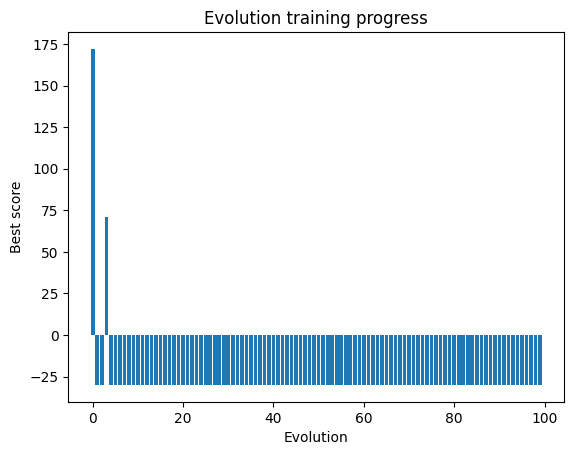

In [30]:
# -------- bar plot of results --------
plt.bar(range(len(best_score_history)), best_score_history)
plt.xlabel("Evolution")
plt.ylabel("Best score")
plt.title("Evolution training progress")
plt.show()